# Transformer Ensemble — Detecção de Scam

Ensemble de 3 Transformers treinados para cada tipo de embedding:
- **Voyage** (1024d) — sequência de mensagens por conversa
- **BGE** (1024d)
- **OpenAI** (3072d)

O ensemble final usa votação por média de probabilidades.

> **Nota:** Os modelos já treinados em `experiment_results/transformer/` são carregados sem re-treinar.


In [1]:
import sys, os

# Garante o posicionamento no diretório 'backend' e no sys.path independente de onde o notebook é executado
current_dir = os.path.abspath(os.getcwd())
backend_dir = None
search_dir = current_dir

while search_dir != os.path.dirname(search_dir):
    if os.path.basename(search_dir) == 'backend' and os.path.exists(os.path.join(search_dir, 'machine_learning')):
        backend_dir = search_dir
        break
    if os.path.exists(os.path.join(search_dir, 'backend', 'machine_learning')):
        backend_dir = os.path.join(search_dir, 'backend')
        break
    if os.path.exists(os.path.join(search_dir, 'HorusEmbbedingPlusML', 'backend', 'machine_learning')):
        backend_dir = os.path.join(search_dir, 'HorusEmbbedingPlusML', 'backend')
        break
    search_dir = os.path.dirname(search_dir)

if backend_dir and os.path.exists(backend_dir):
    os.chdir(backend_dir)
    if backend_dir not in sys.path:
        sys.path.insert(0, backend_dir)

from machine_learning import (
    train_transformer, load_trained_transformers,
    load_transformer_result, load_all_transformer_results,
    evaluate_ensemble, evaluate_ensemble_from_results,
    learning_curve_transformer, ThresholdCalibrator,
    load_sequence_embeddings,
)
import torch

EMBEDDINGS = ["voyage", "bge", "openai"]
WITH_AUGMENTED = True


In [2]:
# import sys, os
# sys.path.insert(0, os.path.abspath('..'))

# from machine_learning import (
#     train_transformer, load_trained_transformers,
#     evaluate_ensemble, learning_curve_transformer,
#     ThresholdCalibrator,
#     load_sequence_embeddings,
# )
# import torch

# EMBEDDINGS = ["voyage", "bge", "openai"]


## 1. Treino dos Transformers (ou carregamento do cache)

In [3]:
# Treina voyage — ou carrega de experiment_results/transformer/voyage__pctnone/
model_voyage_result = train_transformer(
    "voyage", 
    num_epochs=80, 
    lr=2e-6, 
    force_retrain=False, 
    with_augmented=WITH_AUGMENTED
)


[transformer] Cache hit: voyage pct=None
[cache] Carregando Transformer: experiment_results/transformer/voyage__pctnone/model.pth


/home/andrei.pinto/HorusEmbbedingPlusML/backend/machine_learning/cache.py:179: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(path, map_locat

  [plot] Salvo em: /home/andrei.pinto/HorusEmbbedingPlusML/backend/experiment_results/transformer/embedding=voyage__pct=None__strategy=transformer__with_augmented=True/learning_curves.png


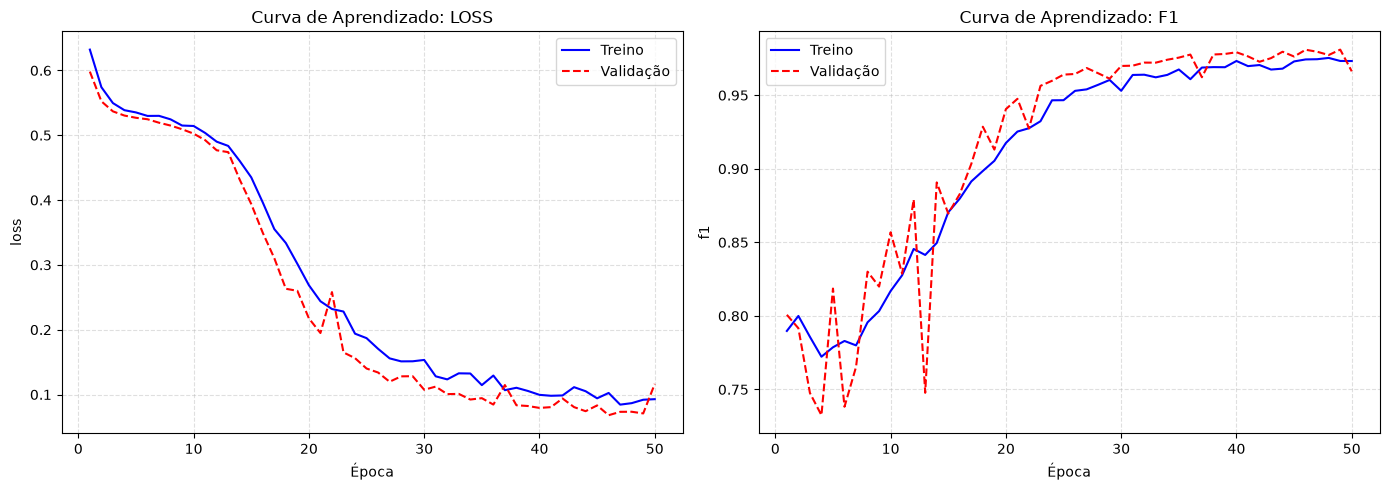

In [4]:
model_voyage_result.plot_learning_curves()


In [5]:
model_bge_result = train_transformer("bge", 
    num_epochs=100, 
    lr=1e-6,
    force_retrain=False, 
    with_augmented=WITH_AUGMENTED
)


[transformer] Cache hit: bge pct=None
[cache] Carregando Transformer: experiment_results/transformer/bge__pctnone/model.pth


/home/andrei.pinto/HorusEmbbedingPlusML/backend/machine_learning/cache.py:179: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(path, map_locat

  [plot] Salvo em: /home/andrei.pinto/HorusEmbbedingPlusML/backend/experiment_results/transformer/embedding=bge__pct=None__strategy=transformer__with_augmented=True/learning_curves.png


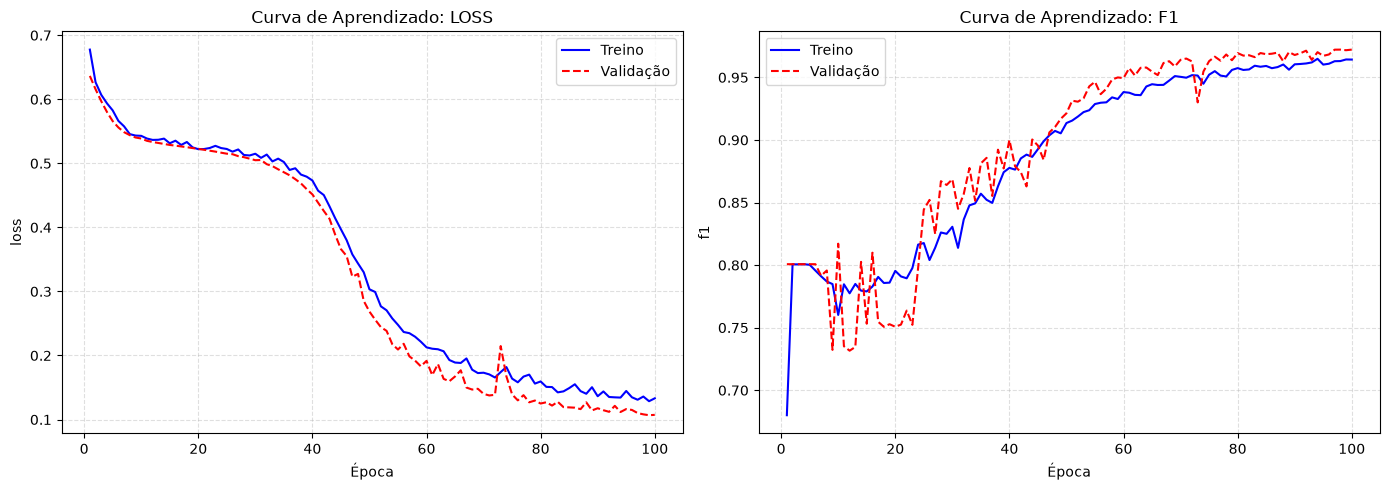

In [6]:
model_bge_result.plot_learning_curves()


In [7]:
model_openai_result = train_transformer(
    "openai", 
    num_epochs=65, 
    lr=1e-6, 
    force_retrain=False, 
    with_augmented=WITH_AUGMENTED
)


[transformer] Cache hit: openai pct=None
[cache] Carregando Transformer: experiment_results/transformer/openai__pctnone/model.pth


/home/andrei.pinto/HorusEmbbedingPlusML/backend/machine_learning/cache.py:179: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(path, map_locat

  [plot] Salvo em: /home/andrei.pinto/HorusEmbbedingPlusML/backend/experiment_results/transformer/embedding=openai__pct=None__strategy=transformer__with_augmented=True/learning_curves.png


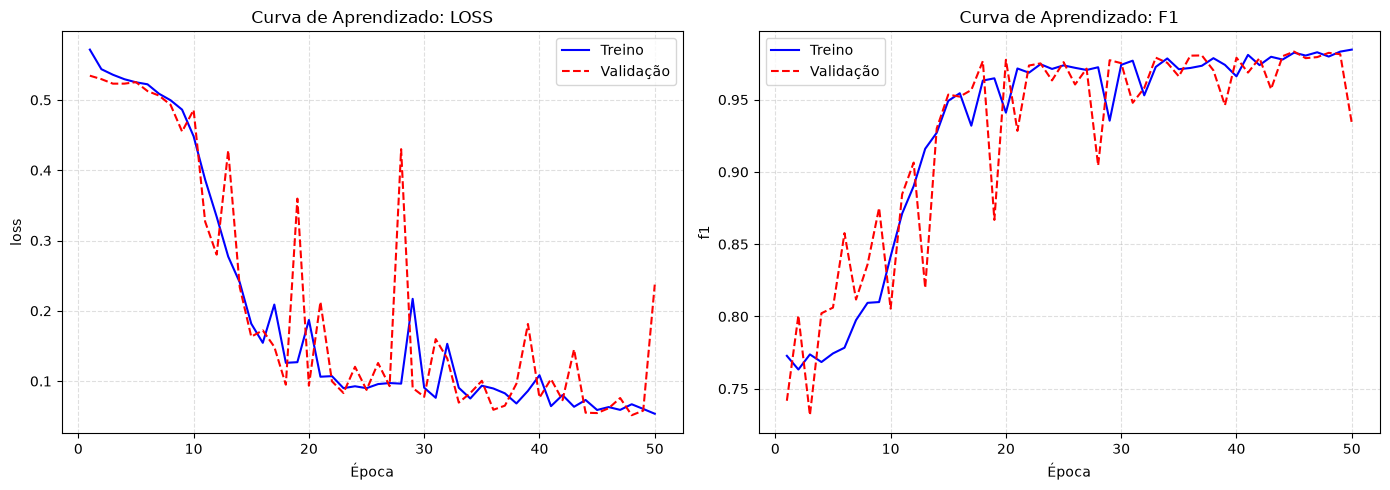

In [8]:
model_openai_result.plot_learning_curves()


## 2. Desempenho individual — conjunto de teste interno

[cache] Carregando Transformer: experiment_results/transformer/voyage__pctnone/model.pth
[cache] Carregando Transformer: experiment_results/transformer/bge__pctnone/model.pth
[cache] Carregando Transformer: experiment_results/transformer/openai__pctnone/model.pth


/home/andrei.pinto/HorusEmbbedingPlusML/backend/machine_learning/cache.py:179: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(path, map_locat

/home/andrei.pinto/HorusEmbbedingPlusML/backend/machine_learning/cache.py:179: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(path, map_locat

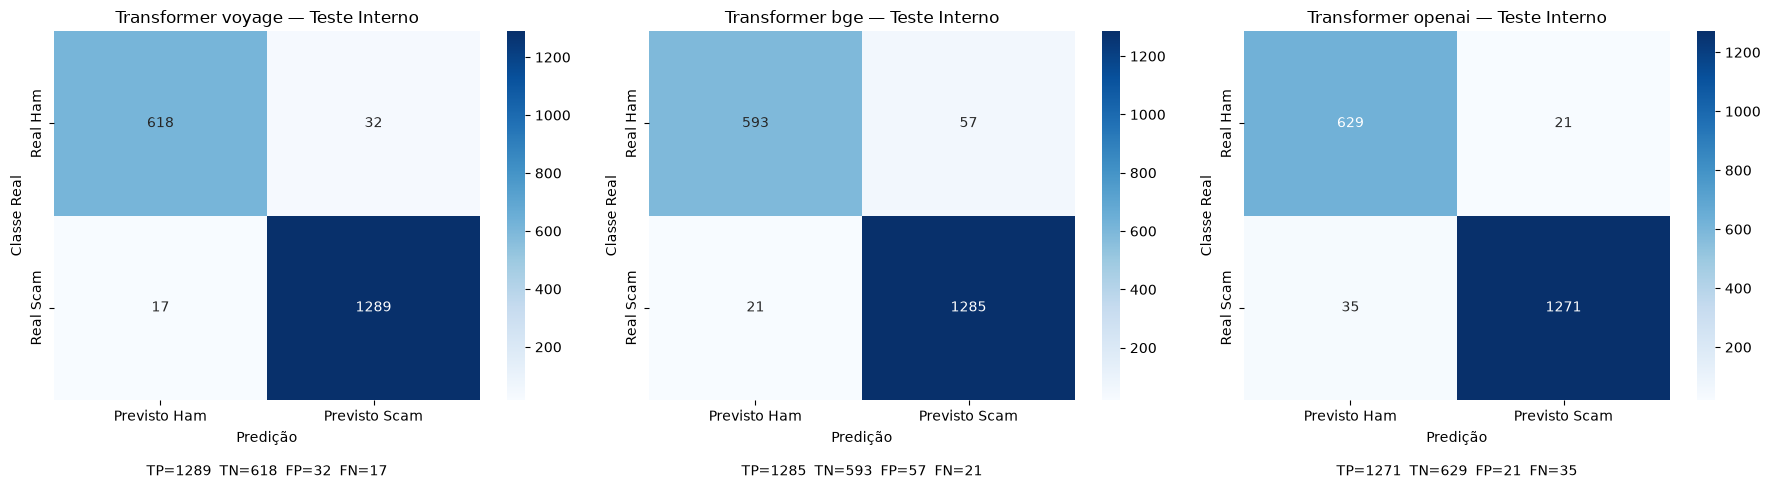

In [9]:
import matplotlib.pyplot as plt
from machine_learning import load_all_transformer_results

# Carrega do disco os resultados salvos do Teste Interno (bloco independente do Tópico 1)
results_test = load_all_transformer_results(EMBEDDINGS, dataset_name="test_internal")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, res, emb in zip(axes, results_test, EMBEDDINGS):
    res.plot_confusion_matrix(title=f"Transformer {emb} — Teste Interno", ax=ax, save=False)
plt.tight_layout()
plt.show()


## 3. Ensemble — votação por média de probabilidades

In [10]:
from machine_learning import evaluate_ensemble_from_results, plot_ensemble_diagnostics

# Avalia o ensemble por Votação por Maioria (2 de 3) no teste interno
ensemble_result = evaluate_ensemble_from_results(results_test, dataset_name="test_interno", voting="majority")



  [Ensemble (Majority Voting - test_interno)] acc=0.9734  f1_macro=0.9700  f1_scam=0.9801


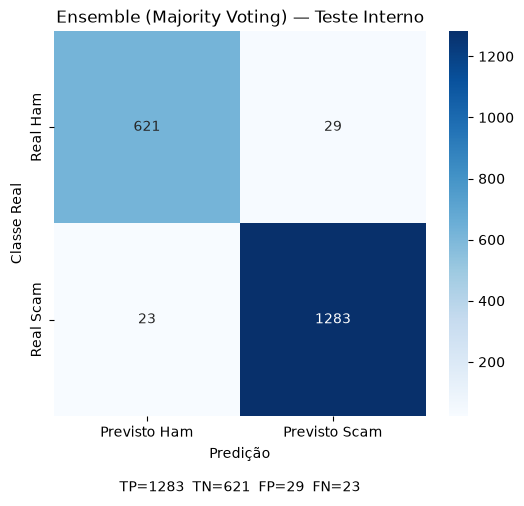

=== RELATÓRIO DETALHADO (Foco na Classe 1: Scam) ===

--- Voyage ---
Precisão (Alarmes verdadeiros): 97.6%
Recall   (Scams capturados):   98.7%
F1-Score (Scam):               98.1%

--- Bge ---
Precisão (Alarmes verdadeiros): 95.8%
Recall   (Scams capturados):   98.4%
F1-Score (Scam):               97.1%

--- Openai ---
Precisão (Alarmes verdadeiros): 98.4%
Recall   (Scams capturados):   97.3%
F1-Score (Scam):               97.8%

--- Ensemble ---
Precisão (Alarmes verdadeiros): 97.8%
Recall   (Scams capturados):   98.2%
F1-Score (Scam):               98.0%



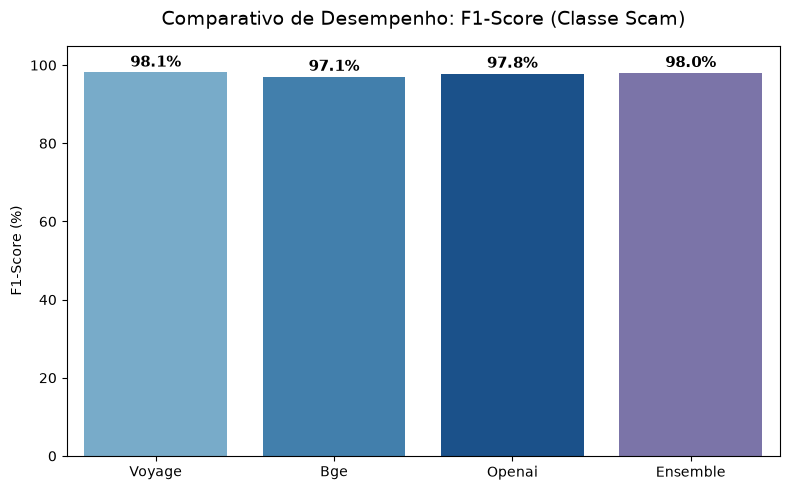

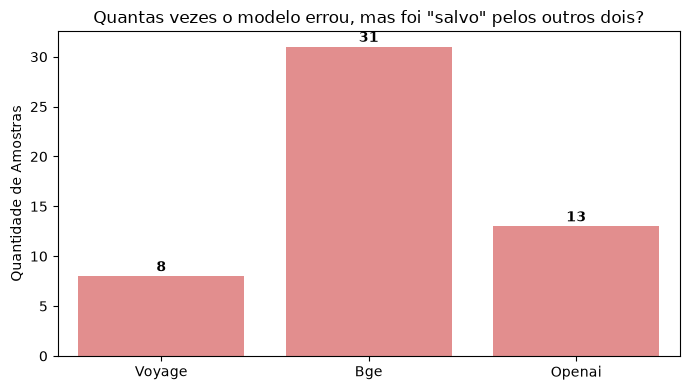

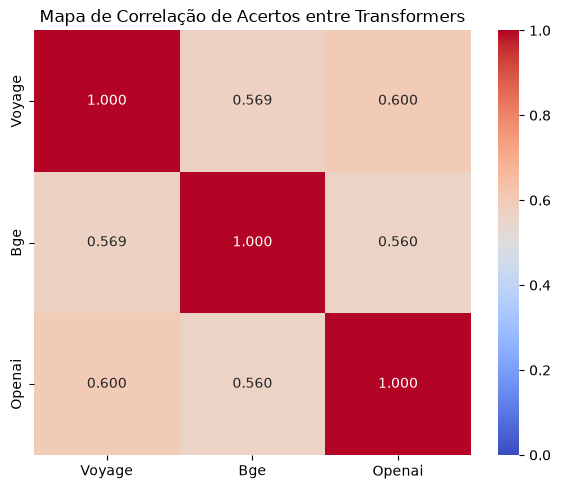

In [11]:
ensemble_result.plot_confusion_matrix(title="Ensemble (Majority Voting) — Teste Interno")

# Diagnósticos: Comparativo F1, Amostras Salvas e Correlação de Acertos
df_diag_test = plot_ensemble_diagnostics(results_test, ensemble_result)


## 4. Avaliação com dataset de validação externo

In [12]:
from machine_learning import load_all_transformer_results, evaluate_ensemble_from_results, plot_ensemble_diagnostics

# Carrega do disco os resultados salvos de Validação Externa
results_val = load_all_transformer_results(EMBEDDINGS, dataset_name="validation")

# Avalia o Ensemble por Votação por Maioria (2 de 3) na Validação Externa
ensemble_val = evaluate_ensemble_from_results(results_val, dataset_name="validacao_externa", voting="majority")


[cache] Carregando Transformer: experiment_results/transformer/voyage__pctnone/model.pth
[cache] Carregando Transformer: experiment_results/transformer/bge__pctnone/model.pth
[cache] Carregando Transformer: experiment_results/transformer/openai__pctnone/model.pth


/home/andrei.pinto/HorusEmbbedingPlusML/backend/machine_learning/cache.py:179: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(path, map_locat


  [Ensemble (Majority Voting - validacao_externa)] acc=0.9224  f1_macro=0.8074  f1_scam=0.6585


/home/andrei.pinto/HorusEmbbedingPlusML/backend/machine_learning/cache.py:179: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(path, map_locat

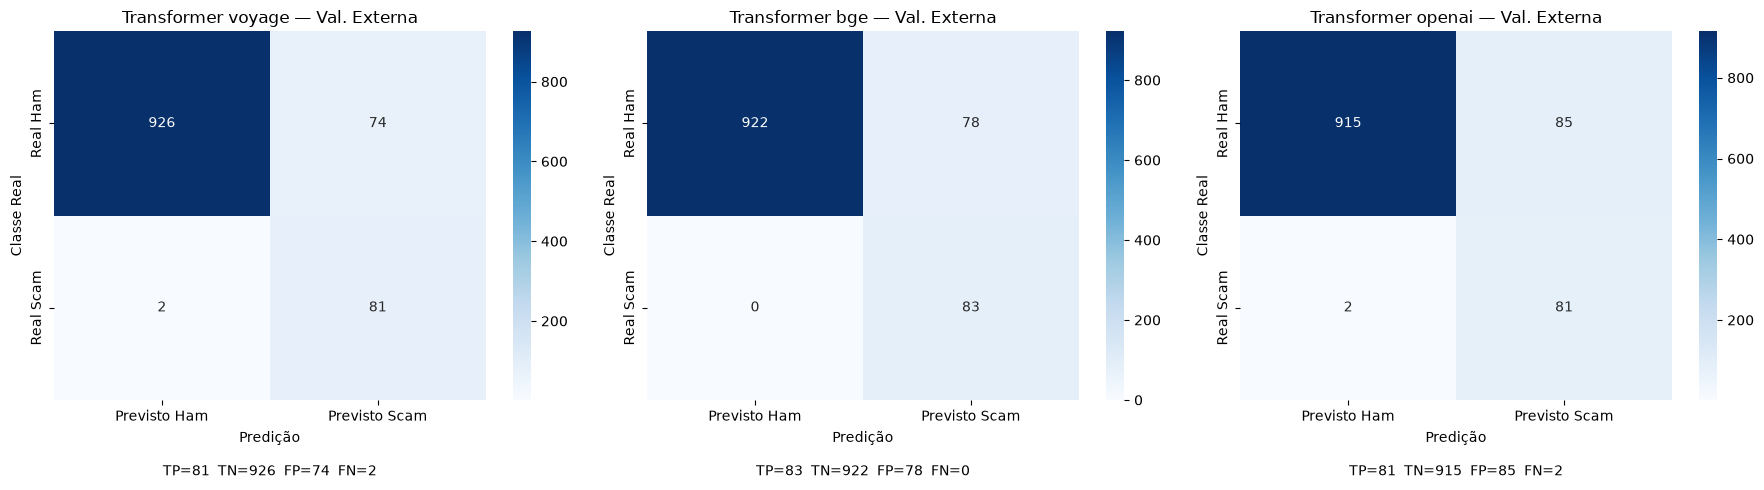

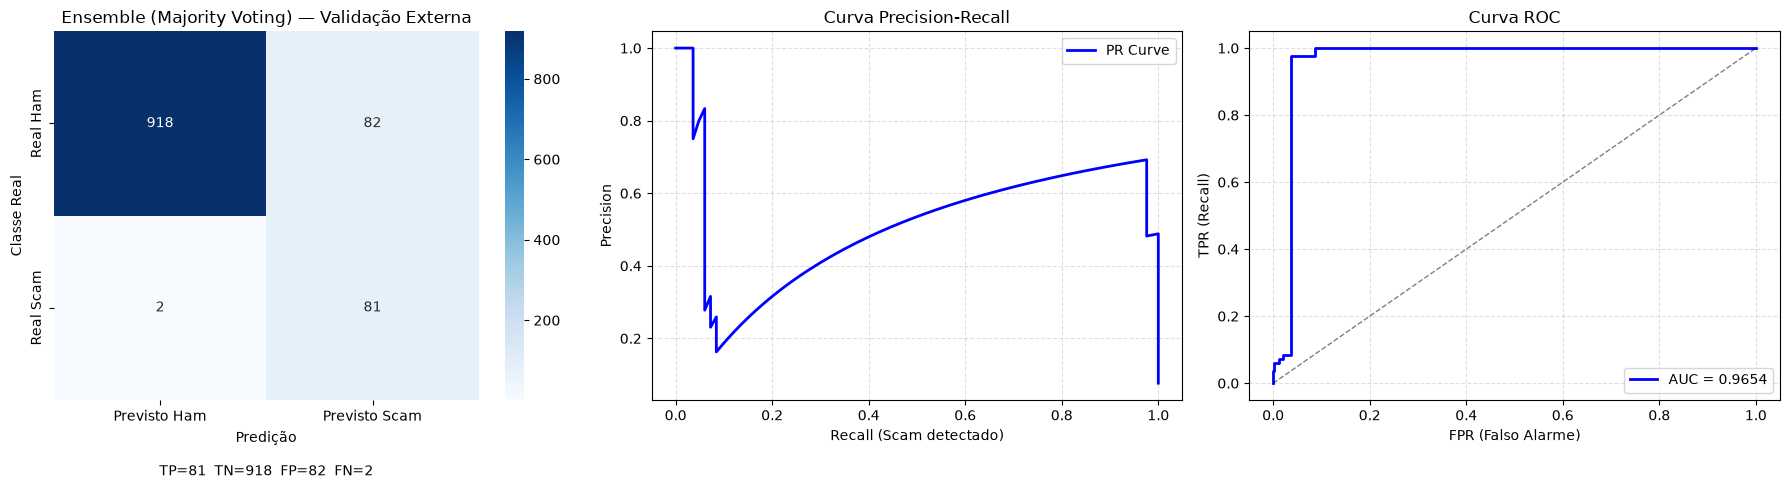

=== RELATÓRIO DETALHADO (Foco na Classe 1: Scam) ===

--- Voyage ---
Precisão (Alarmes verdadeiros): 52.3%
Recall   (Scams capturados):   97.6%
F1-Score (Scam):               68.1%

--- Bge ---
Precisão (Alarmes verdadeiros): 51.6%
Recall   (Scams capturados):   100.0%
F1-Score (Scam):               68.0%

--- Openai ---
Precisão (Alarmes verdadeiros): 48.8%
Recall   (Scams capturados):   97.6%
F1-Score (Scam):               65.1%

--- Ensemble ---
Precisão (Alarmes verdadeiros): 49.7%
Recall   (Scams capturados):   97.6%
F1-Score (Scam):               65.9%



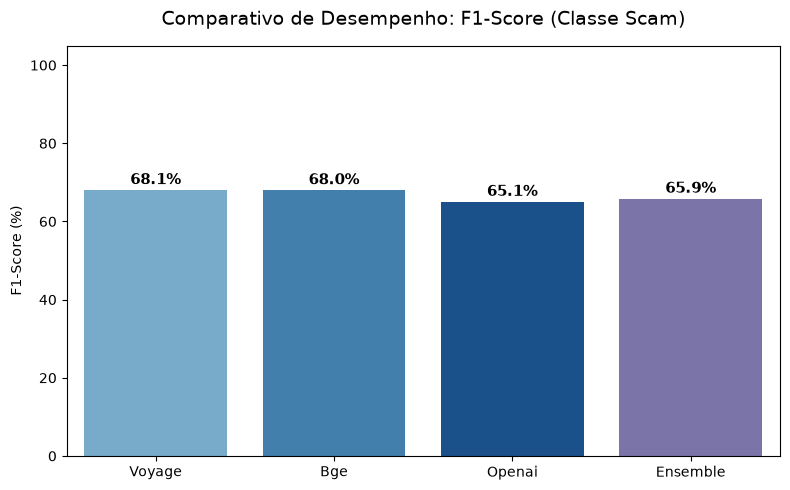

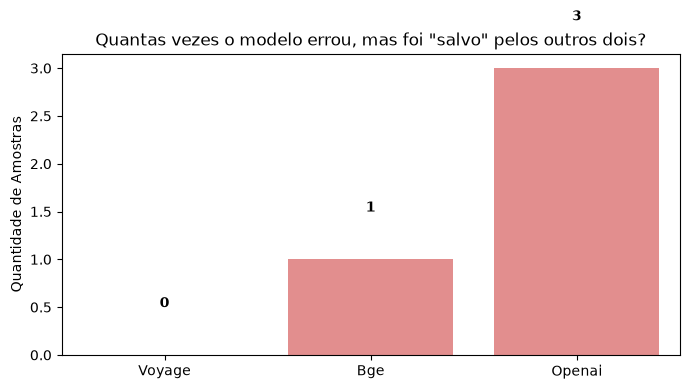

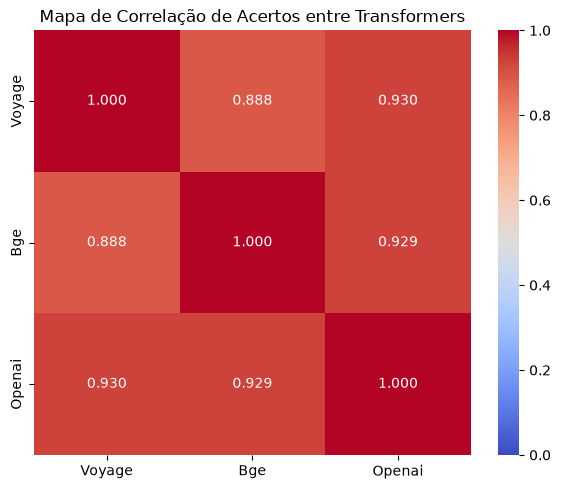

In [13]:
import matplotlib.pyplot as plt

# 1. Matrizes de Confusão dos modelos individuais na Validação Externa
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, res, emb in zip(axes, results_val, EMBEDDINGS):
    res.plot_confusion_matrix(title=f"Transformer {emb} — Val. Externa", ax=ax, save=False)
plt.tight_layout()
plt.show()

# 2. Gráficos do Ensemble na Validação Externa (Matriz de Confusão, Curva PR e Curva ROC)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ensemble_val.plot_confusion_matrix(title="Ensemble (Majority Voting) — Validação Externa", ax=axes[0], save=False)
ensemble_val.plot_precision_recall_curve(ax=axes[1], save=False)
ensemble_val.plot_roc_curve(ax=axes[2], save=False)
plt.tight_layout()
plt.show()

# 3. Análises Diagnósticas na Validação Externa (F1 Comparativo, Amostras Salvas e Correlação)
df_diag_val = plot_ensemble_diagnostics(results_val, ensemble_val)


## 5. Curva de aprendizado por tamanho do dataset

In [14]:
# Carrega histórico dos modelos treinados por % (sem re-treinar)
lc = learning_curve_transformer(embeddings=EMBEDDINGS, percentages=[5, 10, 25, 50, 75, 100])
print(lc.df_history)


   percentual  n_treino  n_val_interna  train_precision  train_recall  \
0           5       390             98         0.733974      0.877395   
1          10       781            196         0.737557      0.938580   
2          25      1955            489         0.837032      0.924904   
3          50      3910            978         0.928857      0.980460   
4          75      5865           1467         0.975240      0.985700   
5         100      7820           1956         0.971651      0.978352   

   train_f1  validation_precision  validation_recall  validation_f1  frac  
0  0.799302              0.090807           0.975904       0.166154  0.05  
1  0.826014              0.090503           0.975904       0.165644  0.10  
2  0.878777              0.109756           0.975904       0.197320  0.25  
3  0.953961              0.199017           0.975904       0.330612  0.50  
4  0.980442              0.485030           0.975904       0.648000  0.75  
5  0.974990              0.48795

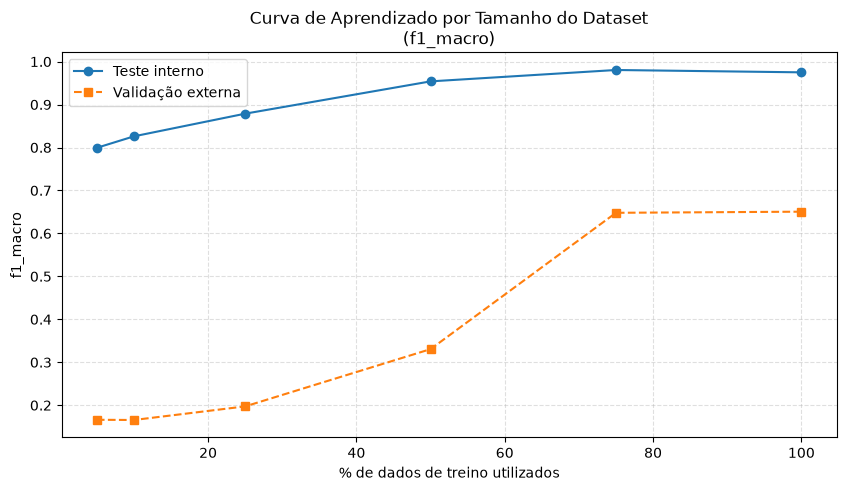

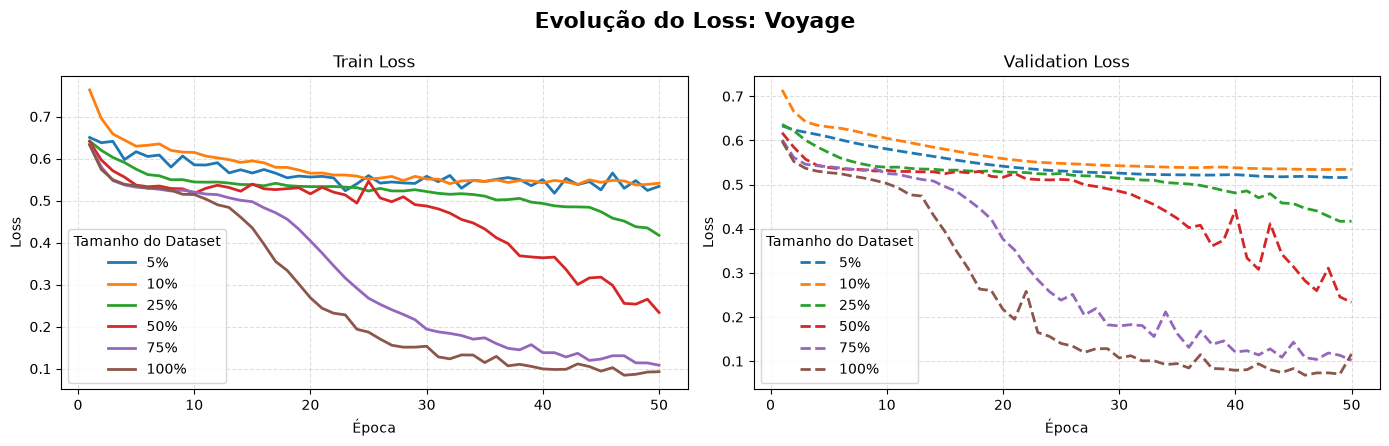

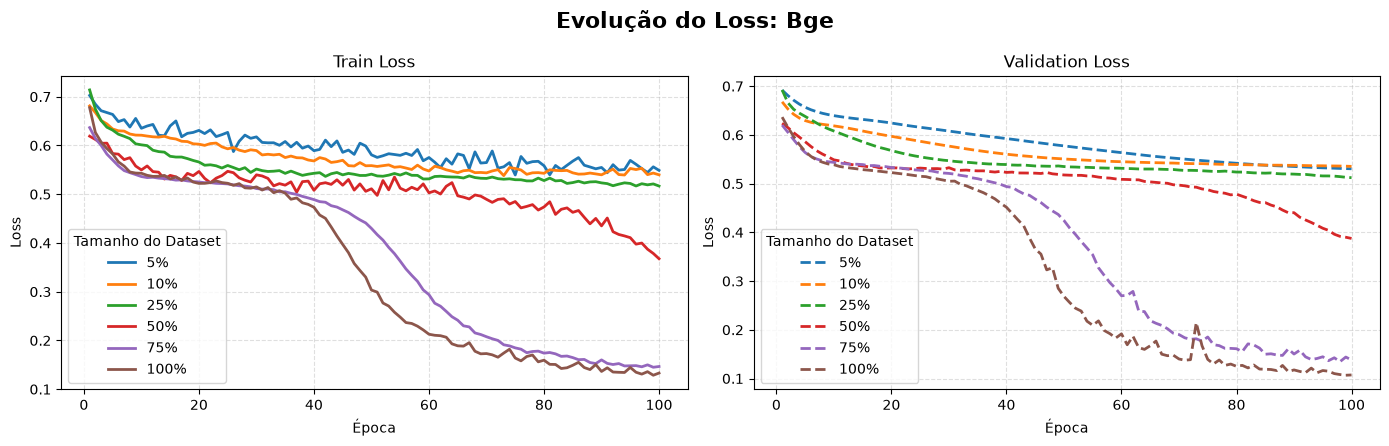

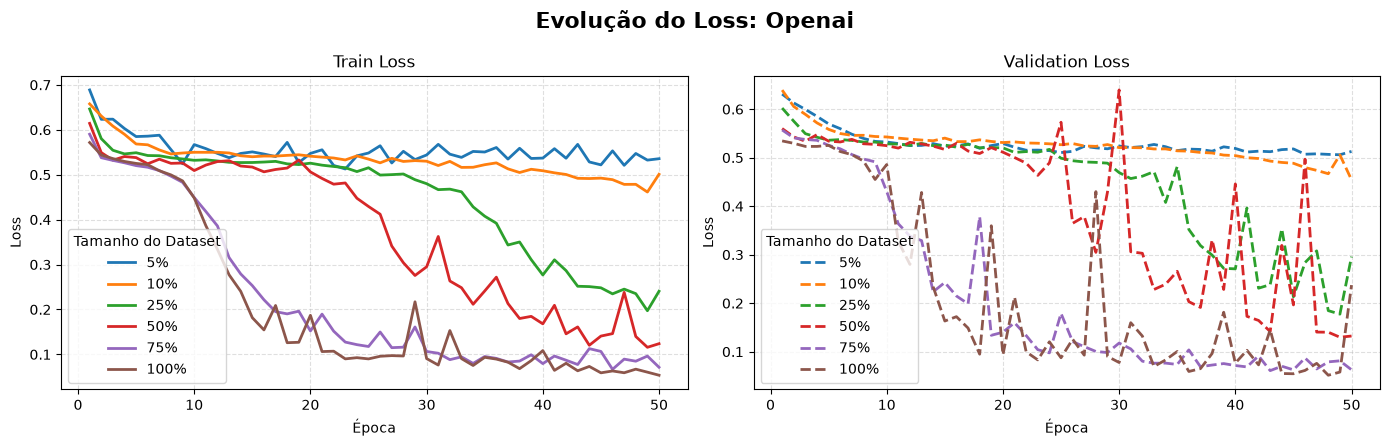

In [15]:
from machine_learning import plot_loss_evolution_all_embeddings

# 1. Curva de aprendizado por % do dataset (% de treino vs F1)
if "frac" in lc.df_history.columns or "percentual" in lc.df_history.columns:
    lc.plot_dataset_size_curve()

# 2. Evolução de Train Loss e Validation Loss por Época para cada embedding (Voyage, BGE, OpenAI)
plot_loss_evolution_all_embeddings()


## 6. Calibração de threshold do Ensemble

[ThresholdCalibrator] Estratégia='min_fn' -> threshold=0.020665


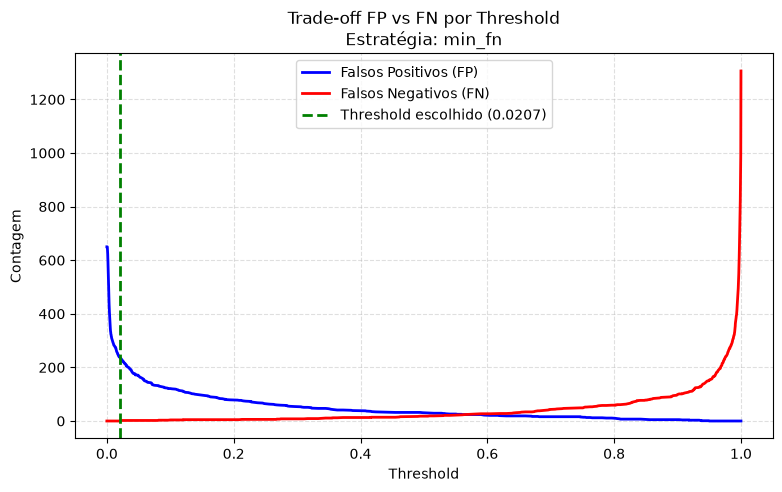

=== Desempenho no Teste Interno (Base de Calibração com Threshold Calibrado) ===

Resultado com threshold=0.020665:
  accuracy: 0.8788
  f1_macro: 0.8469
  f1_scam: 0.9168
  precision_macro: 0.9232
  recall_macro: 0.8177
  precision_scam: 0.8464
  recall_scam: 1.0
  TP: 1306
  TN: 413
  FP: 237
  FN: 0


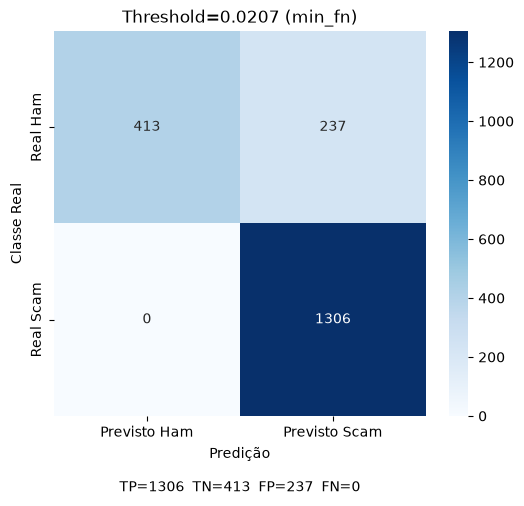

=== Aplicação do Threshold Calibrado na Validação Externa ===

Resultado com threshold=0.020665:
  accuracy: 0.8283
  f1_macro: 0.6845
  f1_scam: 0.4716
  precision_macro: 0.6543
  recall_macro: 0.907
  precision_scam: 0.3086
  recall_scam: 1.0
  TP: 83
  TN: 814
  FP: 186
  FN: 0


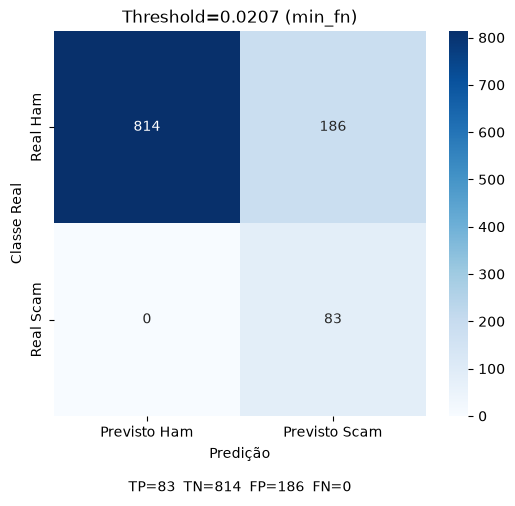

In [16]:
# 6. Calibração de threshold do Ensemble para zerar FN (100% Recall)
if ensemble_result.y_prob is not None:
    calibrator = ensemble_result.calibrate_threshold(strategy="min_fn")
    calibrator.plot_fp_fn_tradeoff()
    
    print("=== Desempenho no Teste Interno (Base de Calibração com Threshold Calibrado) ===")
    calibrator.apply_and_show(ensemble_result.y_true, ensemble_result.y_prob)
    
    print("=== Aplicação do Threshold Calibrado na Validação Externa ===")
    calibrator.apply_and_show(ensemble_val.y_true, ensemble_val.y_prob)
